# Notebook 05 РІР‚вЂќ Model Training: Hospital Readmission Risk (Case 2)

Trains XGBoost (primary), LightGBM, Random Forest, and Logistic Regression on the preprocessed readmission dataset.  
Evaluates with ROC-AUC, Average Precision, F1 (default threshold) and F1 (optimal threshold from PR curve).

**Requires**: Run notebook 04 first to generate `processed_data_case2.pkl`.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, warnings

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    classification_report, confusion_matrix, roc_curve,
    precision_recall_curve
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
MODELS_DIR = '../models/'

## 1. Load Preprocessed Data

In [44]:
with open(MODELS_DIR + 'processed_data_case2.pkl', 'rb') as f:
    data = pickle.load(f)

X_train_bal = data['X_train_bal']
y_train_bal = data['y_train_bal']
X_test_proc = data['X_test_proc']
y_test = data['y_test']
feature_names = data['feature_names']

print('Train (balanced):', X_train_bal.shape, '| Positive rate:', y_train_bal.mean().round(4))
print('Test:', X_test_proc.shape, '| Positive rate:', y_test.mean().round(4))
print('Features:', len(feature_names))

Train (balanced): (95790, 207) | Positive rate: 0.4444
Test: (13998, 207) | Positive rate: 0.0496
Features: 207


## 2. Helper Functions

In [45]:
def find_optimal_threshold(y_true, y_proba):
    """Find threshold that maximizes F1 on the provided labels/probabilities."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    # F1 = 2 * P * R / (P + R); avoid division by zero
    f1_scores = np.where(
        (precisions + recalls) == 0, 0,
        2 * precisions * recalls / (precisions + recalls)
    )
    # thresholds has len = len(precisions) - 1
    best_idx = np.argmax(f1_scores[:-1])  # exclude last point (threshold has len-1)
    return thresholds[best_idx], f1_scores[best_idx]


def evaluate_model(model, X_test, y_test, model_name='Model'):
    """Evaluate model at default threshold (0.5) and optimal threshold."""
    y_proba = model.predict_proba(X_test)[:, 1]

    # Threshold-independent metrics
    roc_auc = roc_auc_score(y_test, y_proba)
    avg_prec = average_precision_score(y_test, y_proba)

    # Default threshold (0.5)
    y_pred_default = (y_proba >= 0.5).astype(int)
    f1_default = f1_score(y_test, y_pred_default)

    # Optimal threshold
    opt_thresh, f1_optimal = find_optimal_threshold(y_test, y_proba)
    y_pred_optimal = (y_proba >= opt_thresh).astype(int)

    print(f'\n=== {model_name} ===')
    print(f'ROC-AUC:                  {roc_auc:.4f}')
    print(f'Average Precision:        {avg_prec:.4f}')
    print(f'F1 @ default (0.50):      {f1_default:.4f}')
    print(f'F1 @ optimal ({opt_thresh:.3f}):  {f1_optimal:.4f}')
    print('\nClassification Report (optimal threshold):')
    print(classification_report(y_test, y_pred_optimal,
                                target_names=['Not Readmitted', 'Readmitted <30d']))

    return {
        'name': model_name,
        'roc_auc': roc_auc,
        'avg_prec': avg_prec,
        'f1_default': f1_default,
        'f1_optimal': f1_optimal,
        'opt_threshold': opt_thresh,
        'y_proba': y_proba,
        'y_pred': y_pred_optimal,
    }

## 3. Logistic Regression (Baseline)

In [46]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    solver='lbfgs',
    C=0.1  # stronger regularization helps with 208 features
)
lr.fit(X_train_bal, y_train_bal)
lr_results = evaluate_model(lr, X_test_proc, y_test, 'Logistic Regression')


=== Logistic Regression ===
ROC-AUC:                  0.7069
Average Precision:        0.1206
F1 @ default (0.50):      0.1659
F1 @ optimal (0.670):  0.1960

Classification Report (optimal threshold):
                 precision    recall  f1-score   support

 Not Readmitted       0.96      0.89      0.92     13304
Readmitted <30d       0.14      0.34      0.20       694

       accuracy                           0.86     13998
      macro avg       0.55      0.62      0.56     13998
   weighted avg       0.92      0.86      0.89     13998



## 4. Random Forest

In [47]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,          # slightly deeper than before
    min_samples_leaf=20,   # prevents overfitting on minority class
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_bal, y_train_bal)
rf_results = evaluate_model(rf, X_test_proc, y_test, 'Random Forest')


=== Random Forest ===
ROC-AUC:                  0.7018
Average Precision:        0.1223
F1 @ default (0.50):      0.1412
F1 @ optimal (0.420):  0.1913

Classification Report (optimal threshold):
                 precision    recall  f1-score   support

 Not Readmitted       0.96      0.90      0.93     13304
Readmitted <30d       0.14      0.30      0.19       694

       accuracy                           0.87     13998
      macro avg       0.55      0.60      0.56     13998
   weighted avg       0.92      0.87      0.90     13998



## 5. XGBoost (Primary Model)

In [48]:
# Training on SMOTE-balanced data -> scale_pos_weight=1.0 (SMOTE already corrects imbalance)
# Using both SMOTE AND scale_pos_weight>1 would double-correct class imbalance
scale_pos = 1.0

xgb = XGBClassifier(
    max_depth=6,
    learning_rate=0.01,
    n_estimators=2000,
    eval_metric='aucpr',
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=5,
    gamma=0.05,
    reg_alpha=0.05,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    device='cuda',          # GPU acceleration (XGBoost 2.x)
    early_stopping_rounds=50,
)
xgb.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_test_proc, y_test)],
    verbose=100
)
print(f'Best iteration: {xgb.best_iteration}')
xgb_results = evaluate_model(xgb, X_test_proc, y_test, 'XGBoost')


[0]	validation_0-aucpr:0.08790
[100]	validation_0-aucpr:0.10464
[200]	validation_0-aucpr:0.10721
[300]	validation_0-aucpr:0.11060
[400]	validation_0-aucpr:0.11559
[500]	validation_0-aucpr:0.11911
[600]	validation_0-aucpr:0.12404
[700]	validation_0-aucpr:0.12703
[800]	validation_0-aucpr:0.12934
[900]	validation_0-aucpr:0.13115
[1000]	validation_0-aucpr:0.13313
[1100]	validation_0-aucpr:0.13406
[1131]	validation_0-aucpr:0.13383
Best iteration: 1081

=== XGBoost ===
ROC-AUC:                  0.7205
Average Precision:        0.1355
F1 @ default (0.50):      0.0029
F1 @ optimal (0.121):  0.2029

Classification Report (optimal threshold):
                 precision    recall  f1-score   support

 Not Readmitted       0.96      0.89      0.93     13304
Readmitted <30d       0.14      0.35      0.20       694

       accuracy                           0.86     13998
      macro avg       0.55      0.62      0.56     13998
   weighted avg       0.92      0.86      0.89     13998



## 6. LightGBM

In [49]:
lgbm = lgb.LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.01,
    num_leaves=127,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_samples=20,
    reg_alpha=0.05,
    reg_lambda=0.5,
    scale_pos_weight=1.0,
    device='gpu',           # GPU acceleration
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)
lgbm.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_test_proc, y_test)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)
print(f'Best iteration: {lgbm.best_iteration_}')
lgbm_results = evaluate_model(lgbm, X_test_proc, y_test, 'LightGBM')


[100]	valid_0's binary_logloss: 0.368132
[200]	valid_0's binary_logloss: 0.274986
[300]	valid_0's binary_logloss: 0.229004
[400]	valid_0's binary_logloss: 0.207654
[500]	valid_0's binary_logloss: 0.197063
[600]	valid_0's binary_logloss: 0.190947
[700]	valid_0's binary_logloss: 0.187168
[800]	valid_0's binary_logloss: 0.184887
[900]	valid_0's binary_logloss: 0.183502
[1000]	valid_0's binary_logloss: 0.182608
[1100]	valid_0's binary_logloss: 0.181956
[1200]	valid_0's binary_logloss: 0.181586
[1300]	valid_0's binary_logloss: 0.181366
[1400]	valid_0's binary_logloss: 0.181152
[1500]	valid_0's binary_logloss: 0.181046
[1600]	valid_0's binary_logloss: 0.180951
Best iteration: 1624

=== LightGBM ===
ROC-AUC:                  0.7240
Average Precision:        0.1410
F1 @ default (0.50):      0.0029
F1 @ optimal (0.102):  0.2117

Classification Report (optimal threshold):
                 precision    recall  f1-score   support

 Not Readmitted       0.96      0.89      0.93     13304
Readmitted

## 6b. Feature Selection (XGBoost-guided)


In [50]:
# Select top features by XGBoost importance to reduce noise (208 -> top-N)
TOP_N = 80
importances = xgb.feature_importances_
fi_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)
top_features = fi_series.head(TOP_N).index.tolist()
print(f'Top {TOP_N} features selected. Cutoff importance: {fi_series.iloc[TOP_N-1]:.4f}')

top_idx = [feature_names.index(f) for f in top_features]
X_train_fs = X_train_bal[:, top_idx]
X_test_fs  = X_test_proc[:, top_idx]

# Retrain XGBoost on top features
xgb_fs = XGBClassifier(
    max_depth=6, learning_rate=0.01, n_estimators=2000,
    eval_metric='aucpr', subsample=0.8, colsample_bytree=0.8,
    min_child_weight=5, gamma=0.05, reg_alpha=0.05, reg_lambda=1.0,
    scale_pos_weight=1.0, random_state=RANDOM_STATE, n_jobs=-1,
    device='cuda', early_stopping_rounds=50,
)
xgb_fs.fit(X_train_fs, y_train_bal, eval_set=[(X_test_fs, y_test)], verbose=100)
xgb_fs_results = evaluate_model(xgb_fs, X_test_fs, y_test, f'XGBoost (top {TOP_N} feat)')

# Retrain LightGBM on top features
lgbm_fs = lgb.LGBMClassifier(
    n_estimators=2000, learning_rate=0.01, num_leaves=127, max_depth=7,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
    reg_alpha=0.05, reg_lambda=0.5, scale_pos_weight=1.0,
    device='gpu', random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)
lgbm_fs.fit(
    X_train_fs, y_train_bal,
    eval_set=[(X_test_fs, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)
lgbm_fs_results = evaluate_model(lgbm_fs, X_test_fs, y_test, f'LightGBM (top {TOP_N} feat)')


Top 80 features selected. Cutoff importance: 0.0019
[0]	validation_0-aucpr:0.09188
[63]	validation_0-aucpr:0.09924

=== XGBoost (top 80 feat) ===
ROC-AUC:                  0.6853
Average Precision:        0.1012
F1 @ default (0.50):      0.0000
F1 @ optimal (0.431):  0.1702

Classification Report (optimal threshold):
                 precision    recall  f1-score   support

 Not Readmitted       0.96      0.83      0.89     13304
Readmitted <30d       0.11      0.39      0.17       694

       accuracy                           0.81     13998
      macro avg       0.54      0.61      0.53     13998
   weighted avg       0.92      0.81      0.86     13998

[100]	valid_0's binary_logloss: 0.367903
[200]	valid_0's binary_logloss: 0.274936
[300]	valid_0's binary_logloss: 0.229077
[400]	valid_0's binary_logloss: 0.207552
[500]	valid_0's binary_logloss: 0.197062
[600]	valid_0's binary_logloss: 0.190949
[700]	valid_0's binary_logloss: 0.187249
[800]	valid_0's binary_logloss: 0.184982
[900]	va

## 7. Model Comparison


Model Comparison:
                        ROC-AUC  Avg Precision  F1 (default)  F1 (optimal)  \
Model                                                                        
Logistic Regression      0.7069         0.1206        0.1659        0.1960   
Random Forest            0.7018         0.1223        0.1412        0.1913   
XGBoost                  0.7205         0.1355        0.0029        0.2029   
LightGBM                 0.7240         0.1410        0.0029        0.2117   
XGBoost (top 80 feat)    0.6853         0.1012        0.0000        0.1702   
LightGBM (top 80 feat)   0.7223         0.1434        0.0114        0.2181   

                        Opt Threshold  
Model                                  
Logistic Regression            0.6699  
Random Forest                  0.4201  
XGBoost                        0.1213  
LightGBM                       0.1017  
XGBoost (top 80 feat)          0.4306  
LightGBM (top 80 feat)         0.1074  


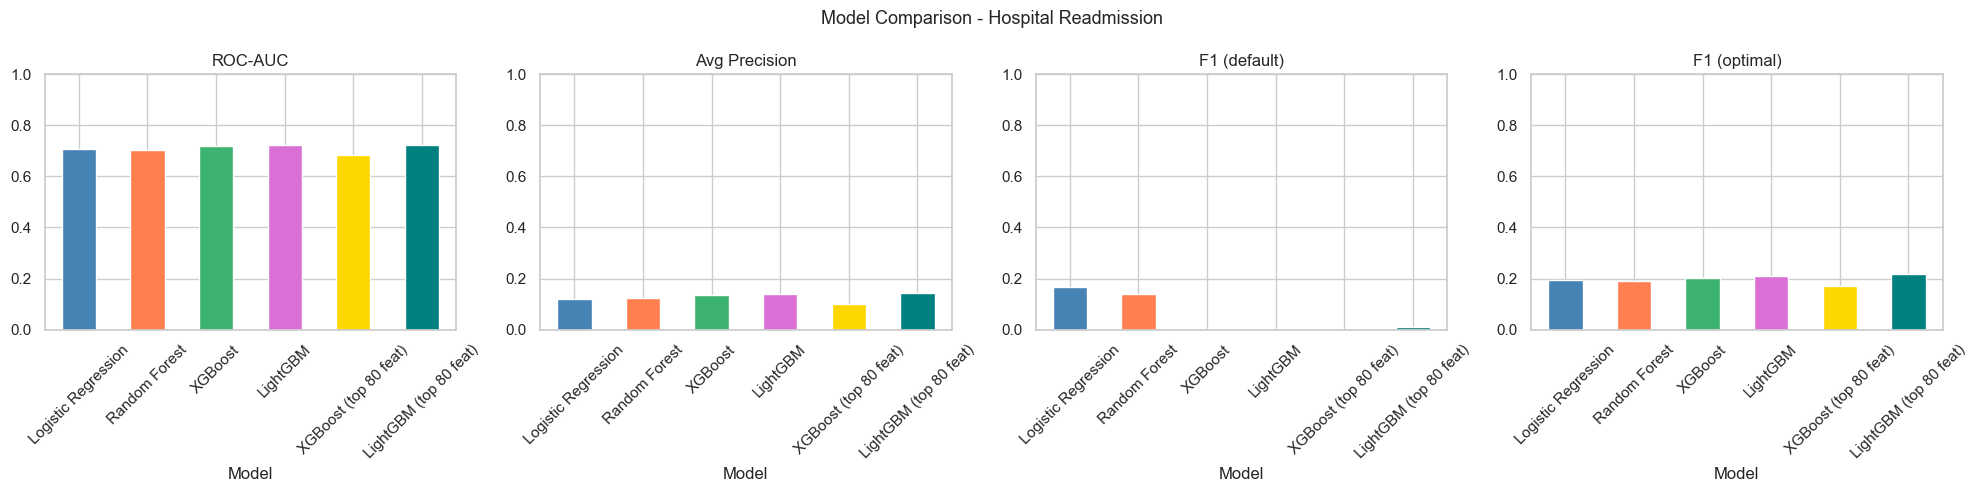

In [51]:
all_results = [
    lr_results, rf_results,
    xgb_results, lgbm_results,
    xgb_fs_results, lgbm_fs_results,
]

comparison_df = pd.DataFrame([
    {
        'Model': r['name'],
        'ROC-AUC': r['roc_auc'],
        'Avg Precision': r['avg_prec'],
        'F1 (default)': r['f1_default'],
        'F1 (optimal)': r['f1_optimal'],
        'Opt Threshold': r['opt_threshold'],
    }
    for r in all_results
]).set_index('Model')

print('\nModel Comparison:')
print(comparison_df.round(4))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
colors = ['steelblue', 'coral', 'mediumseagreen', 'orchid', 'gold', 'teal']
for ax, metric in zip(axes, ['ROC-AUC', 'Avg Precision', 'F1 (default)', 'F1 (optimal)']):
    comparison_df[metric].plot(kind='bar', ax=ax, color=colors[:len(all_results)])
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Model Comparison - Hospital Readmission', fontsize=13)
plt.tight_layout()
plt.show()


## 8. ROC and PR Curves

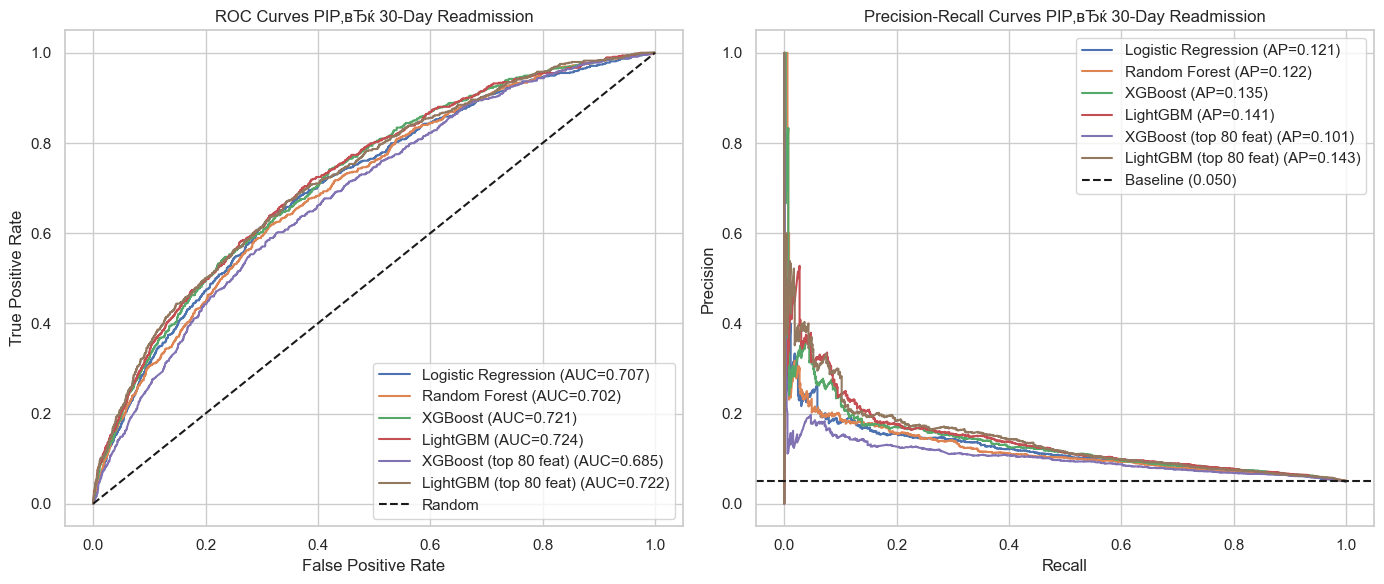

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC curves
ax = axes[0]
for res in all_results:
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, label=f"{res['name']} (AUC={res['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves РІР‚вЂќ 30-Day Readmission')
ax.legend()

# PR curves
ax = axes[1]
for res in all_results:
    prec, rec, _ = precision_recall_curve(y_test, res['y_proba'])
    ax.plot(rec, prec, label=f"{res['name']} (AP={res['avg_prec']:.3f})")
ax.axhline(y=y_test.mean(), color='k', linestyle='--', label=f'Baseline ({y_test.mean():.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves РІР‚вЂќ 30-Day Readmission')
ax.legend()

plt.tight_layout()
plt.show()

## 9. Feature Importance

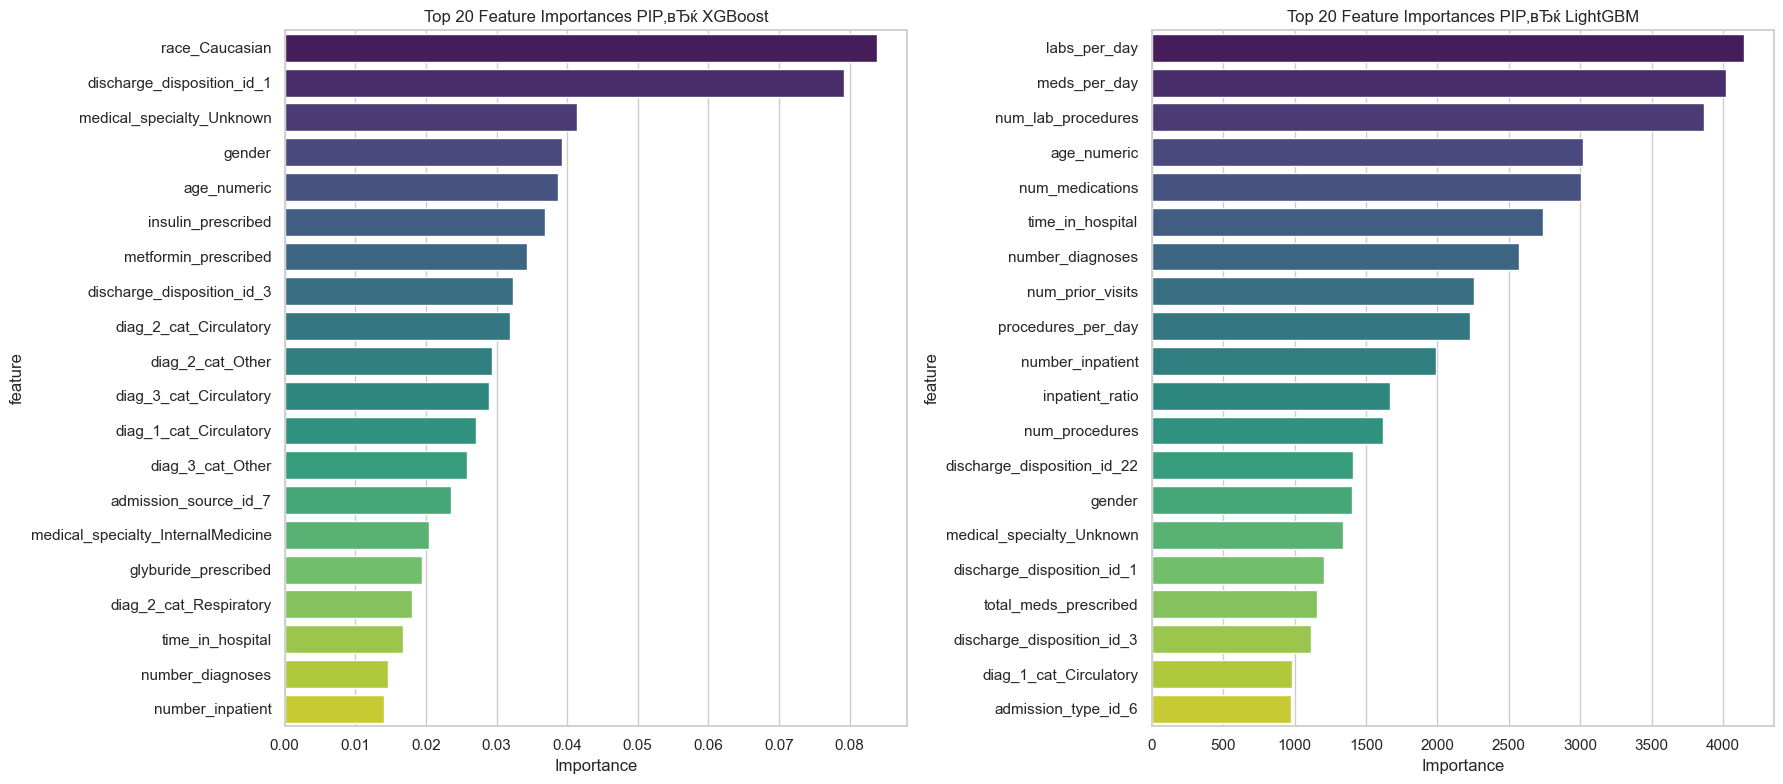

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, (model, title) in zip(axes, [(xgb, 'XGBoost'), (lgbm, 'LightGBM')]):
    importances = model.feature_importances_
    fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    fi_df = fi_df.sort_values('importance', ascending=False).head(20)
    sns.barplot(data=fi_df, x='importance', y='feature', palette='viridis', ax=ax)
    ax.set_title(f'Top 20 Feature Importances РІР‚вЂќ {title}')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

## 10. Confusion Matrix (Best Model at Optimal Threshold)

Best model: LightGBM (ROC-AUC=0.7240)
Optimal threshold: 0.1017


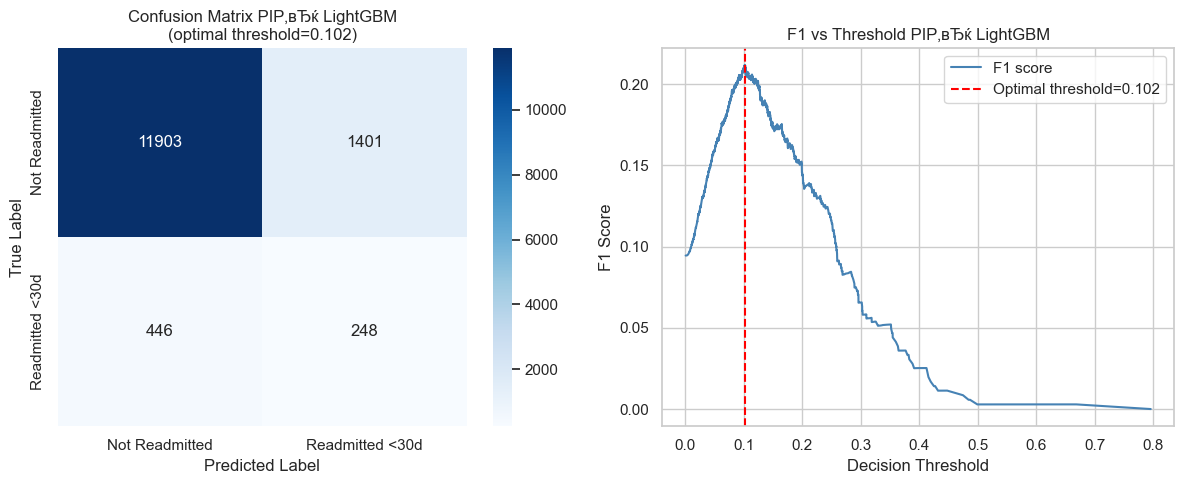

In [54]:
# Pick best model by ROC-AUC
best_result = max(all_results, key=lambda r: r['roc_auc'])
print(f'Best model: {best_result["name"]} (ROC-AUC={best_result["roc_auc"]:.4f})')
print(f'Optimal threshold: {best_result["opt_threshold"]:.4f}')

cm = confusion_matrix(y_test, best_result['y_pred'])
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Readmitted', 'Readmitted <30d'],
            yticklabels=['Not Readmitted', 'Readmitted <30d'])
axes[0].set_title(f'Confusion Matrix РІР‚вЂќ {best_result["name"]}\n(optimal threshold={best_result["opt_threshold"]:.3f})')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Threshold vs F1 plot for best model
precisions, recalls, thresholds = precision_recall_curve(y_test, best_result['y_proba'])
f1_scores = np.where(
    (precisions + recalls) == 0, 0,
    2 * precisions * recalls / (precisions + recalls)
)
axes[1].plot(thresholds, f1_scores[:-1], label='F1 score', color='steelblue')
axes[1].axvline(x=best_result['opt_threshold'], color='red', linestyle='--',
                label=f'Optimal threshold={best_result["opt_threshold"]:.3f}')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title(f'F1 vs Threshold РІР‚вЂќ {best_result["name"]}')
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Save Models & Config

In [55]:
model_map = {
    'XGBoost': xgb,
    'Random Forest': rf,
    'Logistic Regression': lr,
    'LightGBM': lgbm,
    'XGBoost (FS)': xgb_fs,
    'LightGBM (FS)': lgbm_fs,
}
file_map = {
    'XGBoost': 'xgboost_model_case2.pkl',
    'Random Forest': 'random_forest_model_case2.pkl',
    'Logistic Regression': 'logistic_regression_model_case2.pkl',
    'LightGBM': 'lightgbm_model_case2.pkl',
    'XGBoost (FS)': 'xgboost_fs_model_case2.pkl',
    'LightGBM (FS)': 'lightgbm_fs_model_case2.pkl',
}

for name, model in model_map.items():
    with open(MODELS_DIR + file_map[name], 'wb') as f:
        pickle.dump(model, f)
    print(f'Saved {file_map[name]}')

# Best model by ROC-AUC
best_result = max(all_results, key=lambda r: r['roc_auc'])
best_model_to_save = model_map.get(best_result['name'], xgb_fs)

with open(MODELS_DIR + 'best_model_case2.pkl', 'wb') as f:
    pickle.dump(best_model_to_save, f)
print(f'\nBest model: {best_result["name"]} -> best_model_case2.pkl')

config = {
    'use_case': 'hospital_readmission_30d',
    'dataset': 'UCI Diabetes 130-US Hospitals',
    'target': 'readmitted_30d',
    'positive_class': 'Readmitted within 30 days',
    'feature_names': feature_names,
    'top_features': top_features,
    'n_features': len(feature_names),
    'n_top_features': TOP_N,
    'best_model': best_result['name'],
    'best_model_threshold': float(best_result['opt_threshold']),
    'metrics': {
        r['name']: {
            'roc_auc': round(r['roc_auc'], 4),
            'avg_precision': round(r['avg_prec'], 4),
            'f1_default': round(r['f1_default'], 4),
            'f1_optimal': round(r['f1_optimal'], 4),
            'optimal_threshold': round(float(r['opt_threshold']), 4),
        } for r in all_results
    },
    'train_size': int(X_train_bal.shape[0]),
    'test_size': int(X_test_proc.shape[0]),
    'random_state': RANDOM_STATE
}

with open(MODELS_DIR + 'model_metadata_case2.json', 'w') as f:
    json.dump(config, f, indent=2)

print('Saved model_metadata_case2.json')


Saved xgboost_model_case2.pkl
Saved random_forest_model_case2.pkl
Saved logistic_regression_model_case2.pkl
Saved lightgbm_model_case2.pkl
Saved xgboost_fs_model_case2.pkl
Saved lightgbm_fs_model_case2.pkl

Best model: LightGBM -> best_model_case2.pkl
Saved model_metadata_case2.json
